In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [12]:
DATA_PATH = "../data/Gold_features.csv"

FEATURE_COLUMNS = [
    "Close",
    "Volume",
    "RSI",
    "MACD",
    "MACD_Signal"
]

TARGET_COLUMN = "Close"

TIME_STEPS = 60
TRAIN_SIZE = 0.8

In [13]:
def create_sequences(features, target, time_steps):
    X = []
    y = []

    for i in range(time_steps, len(features)):

        # dane wejściowe (60 dni)
        X.append(features[i - time_steps:i])

        # wartość do przewidzenia
        y.append(target[i])

    return np.array(X), np.array(y)

In [14]:
# Wczytanie prawdziwych danych złota

df = pd.read_csv(DATA_PATH)

print(df.head())
print(df.shape)

         Date        Close         High          Low         Open  Volume  \
0  2021-07-02  1782.599976  1787.900024  1778.300049  1778.699951      23   
1  2021-07-06  1793.500000  1809.800049  1786.699951  1786.699951     332   
2  2021-07-07  1801.500000  1808.400024  1797.199951  1798.699951     244   
3  2021-07-08  1799.599976  1818.500000  1797.000000  1797.000000     148   
4  2021-07-09  1810.000000  1810.099976  1798.800049  1803.599976     218   

         RSI       MACD  MACD_Signal  
0  35.587612 -27.457680   -27.827951  
1  40.806028 -25.094853   -27.281332  
2  44.368390 -22.319477   -26.288961  
3  43.695794 -20.042254   -25.039619  
4  48.314390 -17.200071   -23.471710  
(1225, 9)


In [15]:
# Skalowanie danych

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

# cechy wejściowe X
scaled_features = feature_scaler.fit_transform(
    df[FEATURE_COLUMNS]
)

# wartość przewidywana Y
scaled_target = target_scaler.fit_transform(
    df[[TARGET_COLUMN]]
)

print("scaled_features shape:", scaled_features.shape)
print("scaled_target shape:", scaled_target.shape)

scaled_features shape: (1225, 5)
scaled_target shape: (1225, 1)


In [16]:
# Tworzenie sekwencji czasowych

X, y = create_sequences(
    scaled_features,
    scaled_target,
    TIME_STEPS
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1165, 60, 5)
y shape: (1165, 1)


In [17]:
# Podział train/test

train_size = int(len(X) * TRAIN_SIZE)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (932, 60, 5)
y_train: (932, 1)
X_test: (233, 60, 5)
y_test: (233, 1)


In [18]:
# Budowa modelu LSTM

model = Sequential()

# Pierwsza warstwa LSTM
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

# Druga warstwa LSTM
model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

# Warstwa gęsta
model.add(Dense(32, activation="relu"))

# Wyjście
model.add(Dense(1))

# Kompilacja modelu
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Podsumowanie modelu
model.summary()

D:\Project stock-price-prediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,057 (207.25 KB)

 Trainable params: 53,057 (207.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0053 - val_loss: 0.0202
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0011 - val_loss: 0.0024
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.7995e-04 - val_loss: 0.0061
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.1238e-04 - val_loss: 0.0028
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.3859e-04 - val_loss: 0.0125
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.1011e-04 - val_loss: 0.0033
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.5472e-04 - val_loss: 0.0040
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.4714e-04 - val_loss: 0.0212
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.2936e-04 - val_loss: 0.0016
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.5867e-04 - val_loss: 0.0081
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.3295e-04 - val_loss: 0.0028
Epoch 12/20
30/30 ━━━━━━━━━

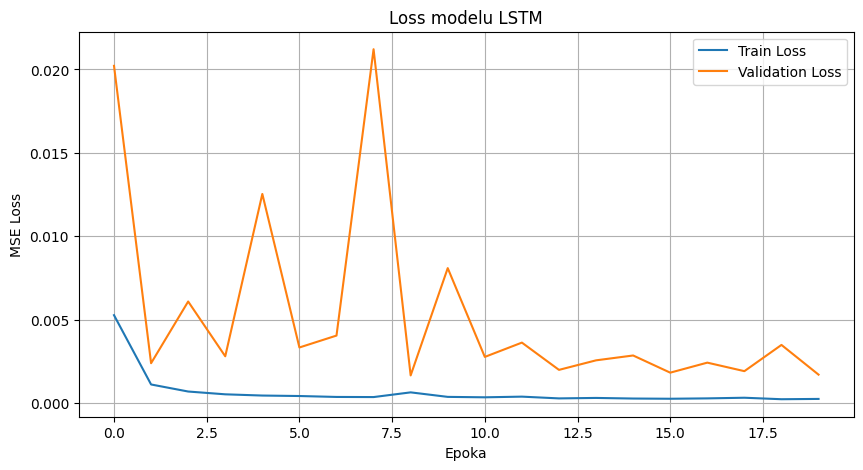

In [20]:
# Wykres strat modelu

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss modelu LSTM")
plt.xlabel("Epoka")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)

plt.show()

In [21]:
# Predykcje modelu

y_pred_scaled = model.predict(X_test)

print(y_pred_scaled[:5])

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[0.4794366 ]
 [0.48302197]
 [0.4859774 ]
 [0.48813573]
 [0.48989278]]


In [22]:
# Zamiana z powrotem na prawdziwe ceny

y_pred = target_scaler.inverse_transform(y_pred_scaled)

y_test_real = target_scaler.inverse_transform(y_test)

print("Predykcje:")
print(y_pred[:5])

print("\nRzeczywiste wartości:")
print(y_test_real[:5])

Predykcje:
[[3394.8662]
 [3408.1145]
 [3419.0352]
 [3427.0103]
 [3433.503 ]]

Rzeczywiste wartości:
[[3431.19995117]
 [3396.39990234]
 [3386.60009766]
 [3389.80004883]
 [3368.10009766]]


In [23]:
mse = mean_squared_error(y_test_real, y_pred)
mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 23110.816567820028
RMSE: 152.02242126679877
MAE: 109.99635151220494


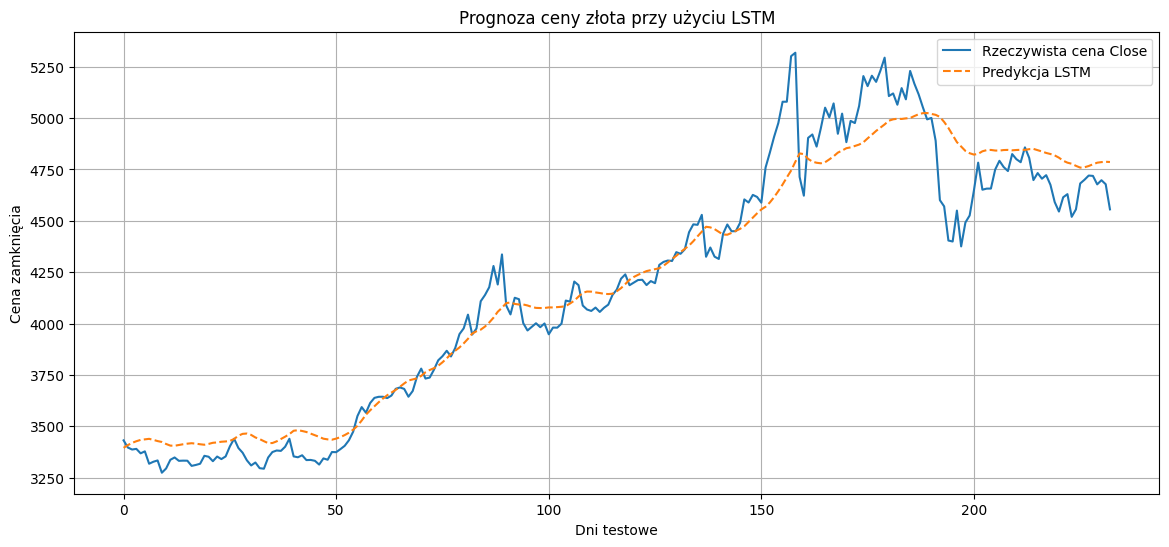

In [24]:
plt.figure(figsize=(14, 6))

plt.plot(y_test_real, label="Rzeczywista cena Close")
plt.plot(y_pred, label="Predykcja LSTM", linestyle="--")

plt.title("Prognoza ceny złota przy użyciu LSTM")
plt.xlabel("Dni testowe")
plt.ylabel("Cena zamknięcia")
plt.legend()
plt.grid(True)

plt.show()